# Optimize CN3S Model

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
from sklearn.metrics import r2_score

from cn3s import CN3S, CN3SOptimizer, CN3SParams


## Load Data

In [2]:
BASIN = "BarraDosBugres"
STATION = 66010000
BASE_FOLDER = "/data/CN3S/basins/"

path = Path(BASE_FOLDER) / BASIN
assert path.exists(), f"Path {path} does not exist"

In [63]:
prec = pd.read_parquet(path / f"Daily_Prec_{STATION}.parquet")
prec.index = prec.index - pd.Timedelta(days=0, hours=12) + pd.Timedelta(days=4)
prec

,prec
time,
2000-01-05,4.962662
2000-01-06,4.615260
2000-01-07,3.587662
2000-01-08,0.001623
2000-01-09,0.389610
...,...
2026-06-15,0.000000
2026-06-16,0.006494
2026-06-17,0.000000


In [64]:
q = pd.read_parquet(path / f"Daily_Q_{STATION}.parquet")
q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1966-01-02,66010000,2,104.26
1966-01-03,66010000,2,107.81
1966-01-04,66010000,2,108.53
1966-01-05,66010000,2,107.81
1966-01-06,66010000,2,99.31
...,...,...,...
2025-12-27,66010000,1,125.14
2025-12-28,66010000,1,115.80
2025-12-29,66010000,1,112.90


## Manual tests

In [10]:
sliced_prec = prec.iloc[-2000:-1000]

In [50]:
AREA = 9642  # km² — update if using a different basin
params = CN3SParams(
    area=AREA,
    r0=100,
    cn_i=120,
    alfa=2,
    beta=5,
    k0=2,
    k1=1.3,
    k2=1.3,
)


model1 = CN3S(model.params)


In [46]:

model1.params.k1=3
model1.run(sliced_prec["prec"].to_list())

Running CN3S model:   0%|          | 0/996 [00:00<?, ?step/s]

In [48]:
model1.results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s
0,10.49513,"[18.154220581054688, 0.030844155699014664, 5.5...",3.0,95.608627,11.666404,0.0,1031.41,37.47,993.94,37.47,139.38
1,4.163149,"[10.495129585266113, 18.154220581054688, 0.030...",3.0,95.608627,11.666404,0.0,1006.43,36.56,969.87,36.56,136.0
2,8.571428,"[4.163149356842041, 10.495129585266113, 18.154...",3.0,95.608627,11.666404,0.0,995.58,36.16,959.42,36.16,134.51
3,0.106331,"[8.571428298950195, 4.163149356842041, 10.4951...",3.0,95.608627,11.666404,0.0,959.74,34.86,924.88,34.86,129.68
4,8.795455,"[0.10633116960525513, 8.571428298950195, 4.163...",3.0,95.608627,11.666404,0.0,951.27,34.55,916.72,34.55,128.52
...,...,...,...,...,...,...,...,...,...,...,...
992,0.00487,"[12.53246784210205, 0.0, 0.0]",3.0,95.608627,11.666404,0.0,52.24,1.9,50.34,1.9,7.07
993,0.0,"[0.004870129749178886, 12.53246784210205, 0.0]",3.0,95.608627,11.666404,0.0,50.34,1.83,48.51,1.83,6.81
994,0.137987,"[0.0, 0.004870129749178886, 12.53246784210205]",3.0,95.608627,11.666404,0.0,48.92,1.78,47.14,1.78,6.62
995,0.001623,"[0.13798701763153076, 0.0, 0.004870129749178886]",3.0,95.608627,11.666404,0.0,47.14,1.71,45.43,1.71,6.36


In [49]:
results = model1.results.copy()
results.index = sliced_prec.index[3:]
results = pd.concat([results, q], axis=1).dropna()

r2_score(results["Vazao"], results["q_m3s"])


-0.03755253353757482

In [93]:
model.params

CN3SParams(area=9642, r0=0, cn_i=7, alfa=0.02, beta=0.002, k0=1, k1=0.3, k2=0.3)

In [ ]:
results = model.results.copy()
results.index = sliced_prec.index[3:]
results = pd.concat([results, q], axis=1).dropna()

r2_score(results["Vazao"], results["q_m3s"])


-0.9946914096974471

## Run Optimizer

In [75]:
sliced_prec = prec.iloc[-2000:-1000]

In [76]:
AREA = 9642  # km² — update if using a different basin

model = CN3S(CN3SParams(area=AREA))

optim = CN3SOptimizer(
    prec=sliced_prec["prec"],
    observed_q=q["Vazao"],
    model=model,
    train_ratio=0.8,
)

print(f"Aligned record: {len(optim.aligned)} time steps")
print(f"Train: {optim.train_idx} | Test: {len(optim.aligned) - optim.train_idx}")

Aligned record: 1000 time steps
Train: 800 | Test: 200


In [78]:
# Interrupt at any time — optim.model will hold the best parameters seen so far.
optim.optimize(maxiter=1000, tol=1e-4, disp=False, workers=-1)

1 - Train NSE: 0.0210 | Test NSE: 0.1688
2 - Train NSE: 0.5406 | Test NSE: 0.5003
3 - Train NSE: 0.5406 | Test NSE: 0.5003
4 - Train NSE: 0.5406 | Test NSE: 0.5003
5 - Train NSE: 0.5406 | Test NSE: 0.5003
6 - Train NSE: 0.5406 | Test NSE: 0.5003
7 - Train NSE: 0.6432 | Test NSE: 0.6029
8 - Train NSE: 0.6432 | Test NSE: 0.6029
9 - Train NSE: 0.7483 | Test NSE: 0.7157
10 - Train NSE: 0.7483 | Test NSE: 0.7157
11 - Train NSE: 0.7483 | Test NSE: 0.7157
12 - Train NSE: 0.7609 | Test NSE: 0.6808
13 - Train NSE: 0.7609 | Test NSE: 0.6808
14 - Train NSE: 0.7609 | Test NSE: 0.6808
15 - Train NSE: 0.7624 | Test NSE: 0.7132
16 - Train NSE: 0.7624 | Test NSE: 0.7132
17 - Train NSE: 0.7654 | Test NSE: 0.7008
18 - Train NSE: 0.7692 | Test NSE: 0.7151
19 - Train NSE: 0.7692 | Test NSE: 0.7151
20 - Train NSE: 0.7748 | Test NSE: 0.6726
21 - Train NSE: 0.7748 | Test NSE: 0.6726
22 - Train NSE: 0.7748 | Test NSE: 0.6726
23 - Train NSE: 0.7748 | Test NSE: 0.6726
24 - Train NSE: 0.7751 | Test NSE: 0.6733
2

Process ForkPoolWorker-67:
Process ForkPoolWorker-72:
Process ForkPoolWorker-69:
Process ForkPoolWorker-71:
Process ForkPoolWorker-68:



Optimization interrupted — best model so far is in `optim.model`.


In [79]:
model.params

CN3SParams(area=9642, r0=822.4829852697771, cn_i=9.379436702350787, alfa=36.12794597556747, beta=3.01111976368853, k0=7.007933208834954, k1=10.294516538326205, k2=0.023382291010210388)

## Evaluate Results

In [80]:
results = optim.model.results.copy()
results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,observed_q
2020-12-31,10.49513,"[18.154220581054688, 0.030844155699014664, 5.5...",5.0,71.464759,101.419935,0.0,930.52527,21.757813,908.767458,21.757813,80.937048,89.21
2021-01-01,4.163149,"[10.495129585266113, 18.154220581054688, 0.030...",5.0,71.464759,101.419935,0.0,951.625068,22.251174,929.373893,22.251174,82.772308,56.35
2021-01-02,8.571428,"[4.163149356842041, 10.495129585266113, 18.154...",5.0,71.464759,101.419935,0.0,1017.612604,23.794114,993.81849,23.794114,88.511901,58.57
2021-01-03,0.106331,"[8.571428298950195, 4.163149356842041, 10.4951...",5.0,71.464759,101.419935,0.0,994.913118,23.263348,971.64977,23.263348,86.537501,58.57
2021-01-04,8.795455,"[0.10633116960525513, 8.571428298950195, 4.163...",5.0,71.464759,101.419935,0.0,1062.194726,24.836546,1037.35818,24.836546,92.389652,58.57
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-19,0.00487,"[12.53246784210205, 0.0, 0.0]",5.0,71.464759,101.419935,0.0,273.026093,6.383976,266.642117,6.383976,23.747798,24.26
2023-09-20,0.0,"[0.004870129749178886, 12.53246784210205, 0.0]",5.0,71.464759,101.419935,0.0,266.642117,6.234704,260.407414,6.234704,23.19252,22.73
2023-09-21,0.137987,"[0.0, 0.004870129749178886, 12.53246784210205]",5.0,71.464759,101.419935,0.0,261.827923,6.122137,255.705787,6.122137,22.773782,21.23
2023-09-22,0.001623,"[0.13798701763153076, 0.0, 0.004870129749178886]",2.135688,23.979141,805.253942,0.0,255.722498,5.979378,249.743121,5.979378,22.242732,21.23


In [81]:
# Split index (adjusted for 3-month warm-up)
split = optim.train_idx - optim._n_warmup

train_nse = r2_score(results.iloc[:split]["observed_q"], results.iloc[:split]["q_m3s"])
test_nse = r2_score(results.iloc[split:]["observed_q"], results.iloc[split:]["q_m3s"])

print(f"Train NSE: {train_nse:.4f}")
print(f"Test  NSE: {test_nse:.4f}")

Train NSE: 0.7483
Test  NSE: 0.7157


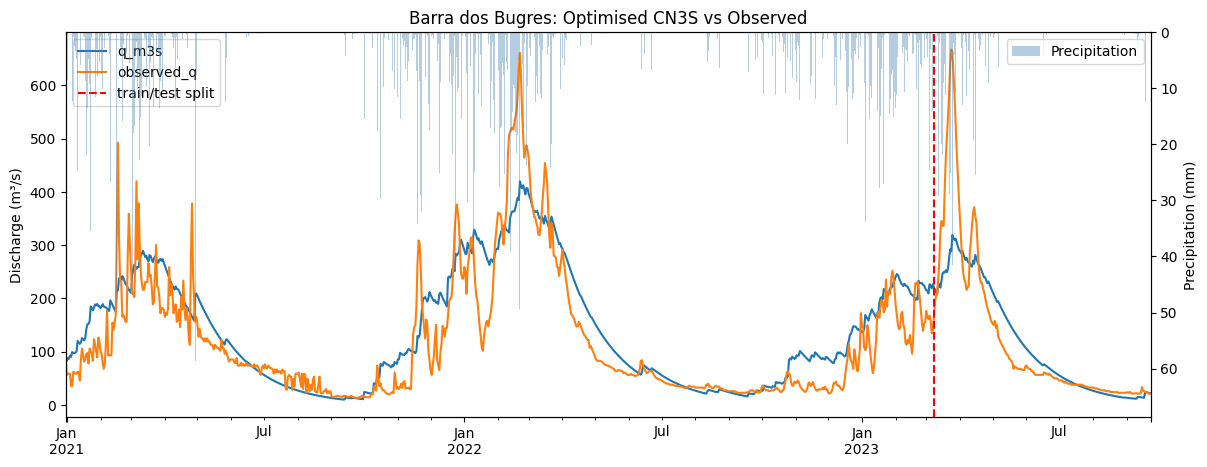

In [82]:
ax = results.plot(
    y=["q_m3s", "observed_q"], figsize=(14, 5), title="Barra dos Bugres: Optimised CN3S vs Observed"
)
ax.axvline(results.index[split], color="red", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set_ylabel("Discharge (m³/s)")

shifted_prec = sliced_prec.shift(0)
ax2 = ax.twinx()
ax2.bar(
    shifted_prec.index, shifted_prec["prec"], color="steelblue", alpha=0.4, label="Precipitation"
)
ax2.invert_yaxis()
ax2.set_ylabel("Precipitation (mm)")
ax2.legend(loc="upper right")

In [74]:
import plotly.graph_objects as go

fig = go.Figure()

# Discharge traces (primary y-axis)
fig.add_trace(
    go.Scatter(x=results.index, y=results["q_m3s"], name="q_m3s", line={"color": "steelblue"})
)
fig.add_trace(
    go.Scatter(
        x=results.index, y=results["observed_q"], name="observed_q", line={"color": "darkorange"}
    )
)

# Train/test split vertical line
split_date = results.index[split]
fig.add_shape(
    type="line",
    x0=split_date,
    x1=split_date,
    y0=0,
    y1=1,
    yref="paper",
    line={"color": "red", "dash": "dash"},
)
fig.add_annotation(
    x=split_date,
    y=1,
    yref="paper",
    text="train/test split",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font={"color": "red"},
)

# Precipitation bars (secondary y-axis, inverted)
fig.add_trace(
    go.Bar(
        x=results.index,
        y=results["prec"],
        name="Precipitation",
        marker_color="steelblue",
        opacity=0.7,
        yaxis="y2",
    )
)

_axis_style = {"showline": True, "linewidth": 1, "linecolor": "black", "mirror": True}

fig.update_layout(
    title="Barra dos Bugres: Optimised CN3S vs Observed",
    xaxis={"title": "Date", **_axis_style},
    yaxis={"title": "Discharge (m³/s)", **_axis_style},
    yaxis2={
        "title": "Precipitation (mm)",
        "overlaying": "y",
        "side": "right",
        "autorange": "reversed",
        **_axis_style,
    },
    legend={"x": 0.01, "y": 0.99},
    height=500,
    width=1000,
    plot_bgcolor="white",
)

fig.show()


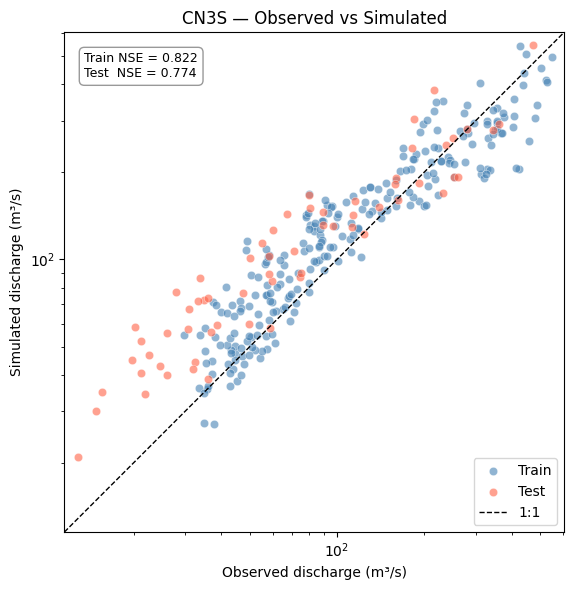

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

# Train and test points with distinct colours
ax.scatter(
    results.iloc[:split]["observed_q"],
    results.iloc[:split]["q_m3s"],
    alpha=0.6,
    label="Train",
    color="steelblue",
    edgecolors="white",
    linewidths=0.4,
)
ax.scatter(
    results.iloc[split:]["observed_q"],
    results.iloc[split:]["q_m3s"],
    alpha=0.6,
    label="Test",
    color="tomato",
    edgecolors="white",
    linewidths=0.4,
)

ax.set_xscale("log")
ax.set_yscale("log")

# 1:1 line spanning the full data range (log-safe: use positive values only)
all_vals = pd.concat([results["observed_q"], results["q_m3s"]])
all_vals = all_vals[all_vals > 0]
lims = [all_vals.min() * 0.9, all_vals.max() * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

ax.set_xlabel("Observed discharge (m³/s)")
ax.set_ylabel("Simulated discharge (m³/s)")
ax.set_title("CN3S — Observed vs Simulated")

# NSE annotation box (top-left)
textstr = f"Train NSE = {train_nse:.3f}\nTest  NSE = {test_nse:.3f}"
ax.text(
    0.04,
    0.96,
    textstr,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "grey", "alpha": 0.8},
    fontsize=9,
)

ax.legend(loc="lower right")
plt.tight_layout()

In [19]:
# Calibrated parameters
optim.model.params

CN3SParams(area=9642, r0=98.95846565107985, cn_i=9.048392320346426, alfa=0.19965320663305813, beta=0.003796888013248299, k0=0.5528689602670063, k1=0.3312926383090628, k2=0.3332066544700027)